In [1]:
# ============================================================
# Angle Encoding과 Entanglement 실습
# ============================================================
# Angle Encoding을 이용한 고전 데이터의 양자 인코딩 실험.
# 정수 데이터를 RY 회전 각도로 변환하여 큐빗 상태로 매핑하고
# 스케일링이 없을 때 발생하는 rotation periodicity 문제를 확인한다.
# Min-Max scaling을 적용하여 데이터 구분 가능성을 개선하고
# 2큐빗 인코딩과 CNOT을 이용한 상호작용(entanglement)을 관찰한다.
#
# 실습 목표
# 1. 고전 데이터를 Angle Encoding 방식으로 큐빗에 인코딩한다.
# 2. Rotation gate의 주기성 때문에 서로 다른 값이 같은 양자 상태로 매핑될 수 있음을 확인한다.
# 3. Min-Max scaling을 통해 단조 매핑을 유지하는 방법을 이해한다.
# 4. 두 개의 데이터를 두 큐빗에 인코딩한다.
# 5. CNOT을 통해 큐빗 간 상호작용(entanglement)이 생성되는 것을 관찰한다.

In [2]:
# ============================================================
# 설치 (Colab용)
# ============================================================

# !pip install pennylane koreanize_matplotlib -q

In [3]:
# ============================================================
# 라이브러리
# ============================================================

import os
import pennylane as qml
from pennylane import numpy as np
import numpy as std_np
import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.rcParams['axes.unicode_minus'] = False

os.makedirs("./fig", exist_ok=True)

In [4]:
# ============================================================
# 파라미터 설정
# ============================================================

# RY rotation 범위
# π/2 -> 범위 좁음
# π   -> 기본
# 2π  -> 주기 반복 다시 발생

scale_max = np.pi


# CNOT 비교용 샘플 인덱스
idx_sample = 25

In [5]:
# ============================================================
# 데이터 생성
# ============================================================

x1 = np.array([2*i + 1   for i in range(50)])    # 홀수
x2 = np.array([2*(i + 1) for i in range(50)])    # 짝수

print("--- 데이터 확인 (처음 5개) ---")
print(f"x1: {x1[:5]}")
print(f"x2: {x2[:5]}")

--- 데이터 확인 (처음 5개) ---
x1: [1 3 5 7 9]
x2: [ 2  4  6  8 10]


In [6]:
# ============================================================
# Device
# ============================================================

dev1 = qml.device("default.qubit", wires=1)
dev2 = qml.device("default.qubit", wires=2)


lab4-1: Angle Encoding 주기 문제
x1=1  -> <Z> = 0.5403
x1=99 -> <Z> = 0.0398
문제: 서로 다른 x1이 같은 상태로 매핑될 수 있음 (rotation 주기)


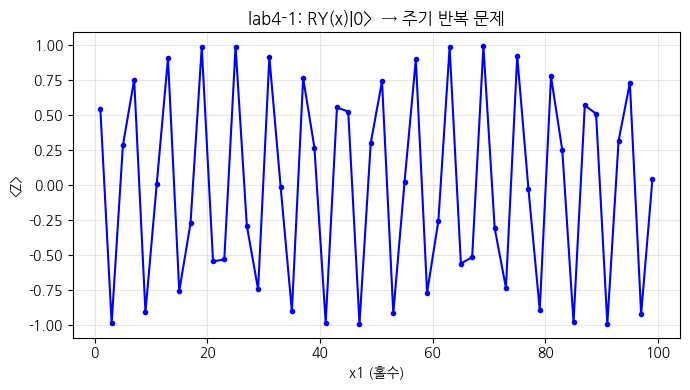

In [7]:
# ============================================================
# lab4-1 : Angle Encoding 주기 문제
# ============================================================

print("\n" + "=" * 60)
print("lab4-1: Angle Encoding 주기 문제")
print("=" * 60)


@qml.qnode(dev1)
def encode_ry(x):
    qml.RY(x, wires=0)
    return qml.expval(qml.PauliZ(0))


ry_vals = np.array([encode_ry(float(x)) for x in x1])

print(f"x1=1  -> <Z> = {float(encode_ry(1.0)):.4f}")
print(f"x1=99 -> <Z> = {float(encode_ry(99.0)):.4f}")
print("문제: 서로 다른 x1이 같은 상태로 매핑될 수 있음 (rotation 주기)")


fig, ax = plt.subplots(figsize=(7,4))
ax.plot(x1, ry_vals, 'bo-', ms=3)
ax.set_xlabel("x1 (홀수)")
ax.set_ylabel("<Z>")
ax.set_title("lab4-1: RY(x)|0>  → 주기 반복 문제")
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig("./fig/lab4a.png", dpi=300)
plt.show()


lab4-2: Min-Max Scaling
scale_max = 3.1416
스케일링 없음: x1=1 -> 0.5403
스케일링 없음: x1=99 -> 0.0398
min-max 적용: x1=1 -> 1.0000
min-max 적용: x1=99 -> -0.9995


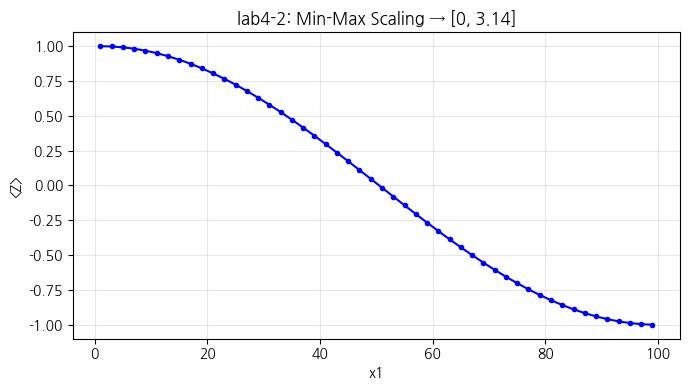


결론
스케일링 없음 → rotation 주기 때문에 정보 손실
min-max scaling → 단조 매핑 유지


In [8]:
# ============================================================
# lab4-2 : Min-Max Scaling
# ============================================================

print("\n" + "=" * 60)
print("lab4-2: Min-Max Scaling")
print("=" * 60)


def scale(x, x_min=1, x_max=100):
    return (x - x_min) / (x_max - x_min) * scale_max


@qml.qnode(dev1)
def circuit_ry(x):
    qml.RY(x, wires=0)
    return qml.expval(qml.PauliZ(0))


results_raw = np.array([circuit_ry(float(x)) for x in x1])
results_scaled = np.array([circuit_ry(scale(x)) for x in x1])


print(f"scale_max = {scale_max:.4f}")
print(f"스케일링 없음: x1=1 -> {results_raw[0]:.4f}")
print(f"스케일링 없음: x1=99 -> {results_raw[-1]:.4f}")

print(f"min-max 적용: x1=1 -> {results_scaled[0]:.4f}")
print(f"min-max 적용: x1=99 -> {results_scaled[-1]:.4f}")


fig, ax = plt.subplots(figsize=(7,4))

ax.plot(x1, results_scaled, 'bo-', ms=3)

ax.set_xlabel("x1")
ax.set_ylabel("<Z>")
ax.set_title(f"lab4-2: Min-Max Scaling → [0, {scale_max:.2f}]")

ax.set_ylim(-1.1,1.1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig("./fig/lab4b.png", dpi=300)
plt.show()


print("\n결론")
print("스케일링 없음 → rotation 주기 때문에 정보 손실")
print("min-max scaling → 단조 매핑 유지")

In [9]:
# ============================================================
# lab4-3 : 2큐빗 Encoding + CNOT
# ============================================================

print("\n" + "=" * 60)
print("lab4-3: 2큐빗 Encoding + CNOT")
print("=" * 60)


@qml.qnode(dev2)
def encode_no_cnot(x1_val, x2_val):

    qml.RY(x1_val, wires=0)
    qml.RY(x2_val, wires=1)

    return qml.probs(wires=[0,1])


@qml.qnode(dev2)
def encode_with_cnot(x1_val, x2_val):

    qml.RY(x1_val, wires=0)
    qml.RY(x2_val, wires=1)

    qml.CNOT(wires=[0,1])

    return qml.probs(wires=[0,1])


x1_sc = float(scale(x1[idx_sample]))
x2_sc = float(scale(x2[idx_sample]))

print(f"샘플 데이터")
print(f"x1 = {int(x1[idx_sample])}")
print(f"x2 = {int(x2[idx_sample])}")

print(f"scaled x1 = {x1_sc:.4f}")
print(f"scaled x2 = {x2_sc:.4f}")


lab4-3: 2큐빗 Encoding + CNOT
샘플 데이터
x1 = 51
x2 = 52
scaled x1 = 1.5867
scaled x2 = 1.6184


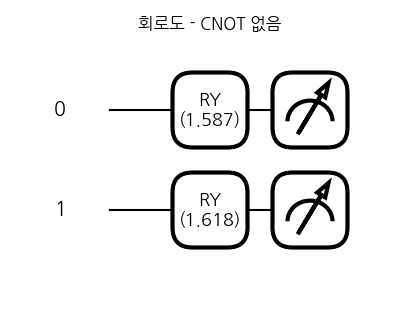

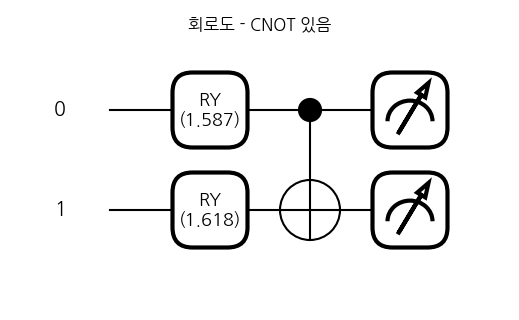

In [10]:
# 회로 그림
fig1, _ = qml.draw_mpl(encode_no_cnot, decimals=3)(x1_sc, x2_sc)
fig1.suptitle("회로도 - CNOT 없음")
fig1.savefig("./fig/lab4c.png", dpi=300)
plt.show()

fig2, _ = qml.draw_mpl(encode_with_cnot, decimals=3)(x1_sc, x2_sc)
fig2.suptitle("회로도 - CNOT 있음")
fig2.savefig("./fig/lab4d.png", dpi=300)
plt.show()

In [11]:
# 확률 계산
p_no = encode_no_cnot(x1_sc, x2_sc)
p_yes = encode_with_cnot(x1_sc, x2_sc)

print("\n확률 분포")

print("CNOT 없음")
print([f"{v:.3f}" for v in p_no])

print("CNOT 있음")
print([f"{v:.3f}" for v in p_yes])


확률 분포
CNOT 없음
['0.234', '0.258', '0.242', '0.266']
CNOT 있음
['0.234', '0.258', '0.266', '0.242']


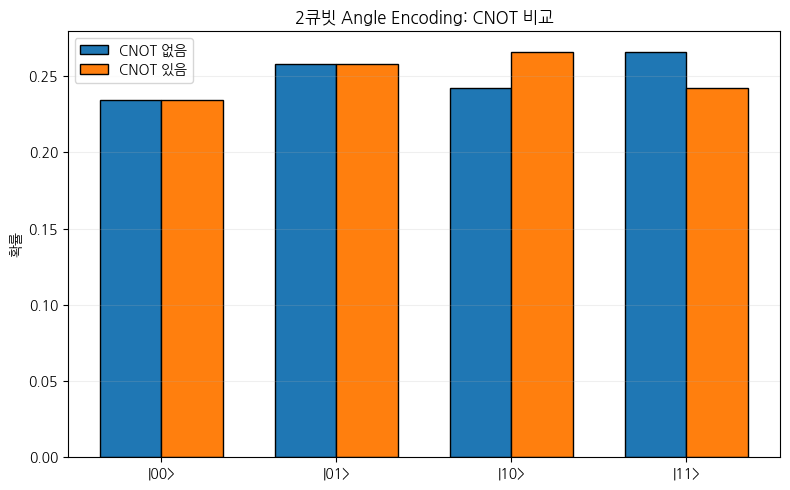

In [12]:
# ============================================================
# 확률 시각화
# ============================================================

basis = ["|00>", "|01>", "|10>", "|11>"]

x_pos = std_np.arange(4)
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

ax.bar(x_pos - width/2, p_no, width, label="CNOT 없음", edgecolor="k")
ax.bar(x_pos + width/2, p_yes, width, label="CNOT 있음", edgecolor="k")

ax.set_xticks(x_pos)
ax.set_xticklabels(basis)

ax.set_ylabel("확률")
ax.set_title("2큐빗 Angle Encoding: CNOT 비교")

ax.legend()
ax.grid(True, axis="y", alpha=0.2)

plt.tight_layout()
fig.savefig("./fig/lab4e.png", dpi=300)

plt.show()

In [13]:
# ============================================================
# 핵심 정리
# ============================================================

print("\n핵심 개념")

print("1. Angle Encoding → 데이터 → rotation angle")
print("2. Rotation gate는 주기성을 가짐")
print("3. Scaling 없으면 서로 다른 데이터가 같은 상태가 될 수 있음")
print("4. Min-Max Scaling → 단조 매핑 유지")
print("5. CNOT → 큐빗 간 상호작용 생성")


핵심 개념
1. Angle Encoding → 데이터 → rotation angle
2. Rotation gate는 주기성을 가짐
3. Scaling 없으면 서로 다른 데이터가 같은 상태가 될 수 있음
4. Min-Max Scaling → 단조 매핑 유지
5. CNOT → 큐빗 간 상호작용 생성
